<a href="https://colab.research.google.com/github/JuanZapa7a/AINavalEngineering/blob/main/CS3b-medium_swh_probability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div class="output_png output_subarea output_execute_result">
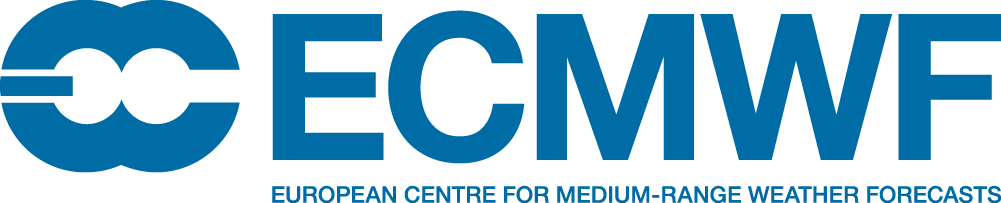
</div>

# 	Probabilities: significant wave height

This notebook will provide you guidance how to explore and plot ECMWF open dataset to produce the map from the ECMWF open charts web product.  
The original product can be found on this link: https://charts.ecmwf.int/products/medium-swh-probability  


<div class="output_png output_subarea output_execute_result">
<center>
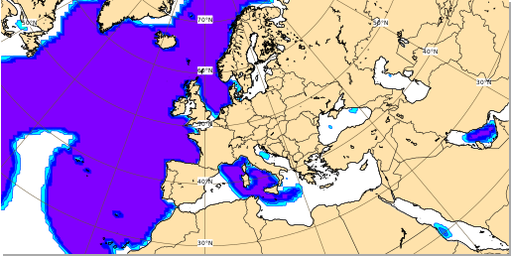</center>
</div>

The full list of available Open data products can be found [here](https://www.ecmwf.int/en/forecasts/datasets/open-data), and more information can be found in the [User documentation](https://confluence.ecmwf.int/display/DAC/ECMWF+open+data%3A+real-time+forecasts+from+IFS+and+AIFS).  

Access to ECMWF Open data is governed by the Creative Commons CC-BY-4.0 licence and associated [Terms of Use](https://apps.ecmwf.int/datasets/licences/general/).  

<sub> In applying this licence, ECMWF does not waive the privileges and immunities granted to it by virtue of its status as an intergovernmental organisation nor does it submit to any jurisdiction </sub>

To find out how to obtain the access to the full forecast dataset at higher resolution please visit our [Access page](https://www.ecmwf.int/en/forecasts/accessing-forecasts).

## Retrieve Data
This product takes in input one of these 4 parameters:

* [Significant wave height of at least 2 m](https://codes.ecmwf.int/grib/param-db/131074)
* [Significant wave height of at least 4 m](https://codes.ecmwf.int/grib/param-db/131075)
* [Significant wave height of at least 6 m](https://codes.ecmwf.int/grib/param-db/131076)
* [Significant wave height of at least 8 m](https://codes.ecmwf.int/grib/param-db/131077)

These are already calculated probabilities, so no need to download all ensemble members.

In this example, we will use:
- [**ecmwf.opendata**](https://github.com/ecmwf/ecmwf-opendata) Client to download the data


First we need to install them in the current Jupyter kernel:  
<div class="alert alert-block alert-info">
<b>Note:</b> If you are running the notebook on MyBinder or already have the libraries installed, go directly to importing the libraries.
</div>
<div class="alert alert-block alert-info">
<b>Note:</b> If you don't have these libraries installed, click on three dots below, uncomment the code and run the next two cells.
</div>

In [1]:
!pip install cfgrib xarray cartopy eccodes ecmwf-opendata

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 103.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.5/83.5 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 89.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 114.1 MB/s eta 0:00:00


In [2]:
from ecmwf.opendata import Client
client=Client("ecmwf", beta=False)
parameters=['swhg2','swhg4','swhg6','swhg8']
filename='medium-swh-probability.grib'
client.retrieve(date=-1,time=0,step=48,stream='waef',type='ep',levtype='sfc',param=parameters,target=filename)


20251113000000-240h-waef-ep.grib2:   0%|          | 0.00/757k [00:00<?, ?B/s]

By downloading data from the ECMWF open data dataset, you agree to the terms: Attribution 4.0 International (CC BY 4.0). Please attribute ECMWF when downloading this data.


Setting date to 0 will download today's data.
Removing date and time altogether from the request will download the latest data.  
Try commenting out date and time to download latest forecast!

In [3]:
client.retrieve(
    date=-1,
    time=0,
    step=48,
    stream="waef",
    type='ep',
    levtype="sfc",
    param=parameters,
    target=filename
)

20251113000000-240h-waef-ep.grib2:   0%|          | 0.00/757k [00:00<?, ?B/s]

## Reading and processing the data
Now we can use **xarray** to read the file.

In [5]:
import xarray as xr

In [8]:
data = xr.open_dataset(filename, engine='cfgrib')
data

<xarray.Dataset> Size: 17MB
Dimensions:     (latitude: 721, longitude: 1440)
Coordinates:
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
    time        datetime64[ns] 8B ...
    step        timedelta64[ns] 8B ...
    meanSea     float64 8B ...
    valid_time  datetime64[ns] 8B ...
Data variables:
    swhg8       (latitude, longitude) float32 4MB ...
    swhg4       (latitude, longitude) float32 4MB ...
    swhg6       (latitude, longitude) float32 4MB ...
    swhg2       (latitude, longitude) float32 4MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-11-14T11:36 GRIB to CDM+CF via cfgrib-0.9.1...

And an overview of one parameter, where we can see more information, such as units or type of level.

In [10]:
swhg4 = data['swhg4']
swhg4

<xarray.DataArray 'swhg4' (latitude: 721, longitude: 1440)> Size: 4MB
[1038240 values with dtype=float32]
Coordinates:
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
    time        datetime64[ns] 8B ...
    step        timedelta64[ns] 8B ...
    meanSea     float64 8B ...
    valid_time  datetime64[ns] 8B ...
Attributes: (12/30)
    GRIB_paramId:                             131075
    GRIB_dataType:                            ep
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         meanSea
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_name:                                Significant wave height of at l...
    GRIB_shortName:                           swhg4
    GRIB_units:                               %
    long_name:                                Significant wave height of at l...
    units:                                    %
    standard_name:                            unknown

We can use **ls()** function to list all the fields in the file we downloaded.

## Plotting the data
And finally, we can plot the data on the map.

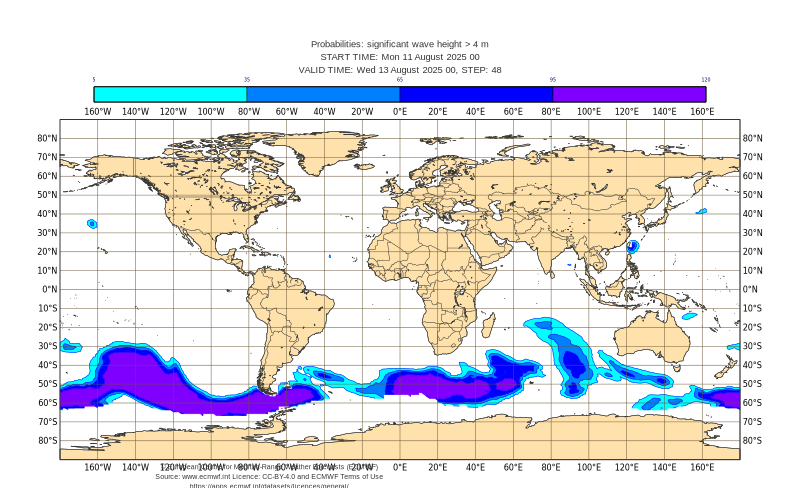

In [ ]:
# define coastlines
coast = mv.mcoast(
    map_coastline_colour="charcoal",
    map_coastline_resolution="medium",
    map_coastline_land_shade="on",
    map_coastline_land_shade_colour="cream",
    map_coastline_sea_shade="off",
    map_boundaries="on",
    map_boundaries_colour= "charcoal",
    map_boundaries_thickness = 1,
    map_disputed_boundaries = "off",
    map_grid_colour="tan",
    map_label_height=0.35,
)

# Definir la vista de Europa y el estilo de las isobaras
view = mv.geoview(
    map_area_definition="corners",
    #area=[30, -20, 70, 40],  # Europa: [lat_min, lon_min, lat_max, lon_max]
    area=[-90, -180, 90, 180],
    coastlines=coast,
)

#define styles
swhg4_shade = mv.mcont(legend= "on",
                contour_automatics_settings = "style_name",
                contour_style_name = "sh_blup_f0t100lst")

title = mv.mtext(
    text_lines=["Probabilities: significant wave height > 4 m",
           "START TIME: <grib_info key='base-date' format='%a %d %B %Y %H'/> ",
           "VALID TIME: <grib_info key='valid-date' format='%a %d %B %Y %H'/>, STEP: <grib_info key='step' />"],
    text_font_size=0.4,
    text_colour         = 'charcoal')

ecmwf_text = mv.mtext(
    text_lines          = ["© European Centre for Medium-Range Weather Forecasts (ECMWF)",
                           "Source: www.ecmwf.int Licence: CC-BY-4.0 and ECMWF Terms of Use",
                            "https://apps.ecmwf.int/datasets/licences/general/"],
    text_justification  = 'center',
    text_font_size      = 0.3,
    text_mode           = "positional",
    text_box_x_position = 6.,
    text_box_y_position = -0.2,
    text_box_x_length   = 8,
    text_box_y_length   = 2,
    text_colour         = 'charcoal')

# generate plot
mv.setoutput('jupyter', plot_widget=False)
mv.plot(view, swhg4, swhg4_shade, title, ecmwf_text)

To generate the png file you can run the following cell.

In [ ]:
png = mv.png_output(
      output_name = "medium-swh-probability",   # specify relative or full path
      output_title = "medium-swh-probability",    # title used by a viewer
      output_width = 1000,                 # set width in pixels
)
mv.setoutput(png)
mv.plot(view, swhg4, swhg4_shade, title, ecmwf_text)

Note that plot produced using open data dataset will slightly differ from one from Open Charts. This is due to different resolution of the data.  
Open data is on 0.25x0.25 resolution, while high resolution data is 0.1x0.1 grid.